# MarketLens Stage 4: Feature Engineering

This notebook adds financial analysis features to the cleaned MarketLens dataset.

Input:
- `data/processed/marketlens_dataset.csv`

Output:
- `data/processed/marketlens_features.csv`

Features added:
- daily_return
- cumulative_return
- moving_average_20
- moving_average_50
- rolling_volatility_20
- rsi_14
- drawdown
- trend_status

#### Imports and project root

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(r"C:\Users\Wilson\Documents\OpenAI\MarketLens")
os.chdir(PROJECT_ROOT)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:")
print(Path.cwd())

print("\nProcessed data folder:")
print(PROCESSED_DIR)

Current working directory:
C:\Users\Wilson\Documents\OpenAI\MarketLens

Processed data folder:
C:\Users\Wilson\Documents\OpenAI\MarketLens\data\processed


#### Load cleaned dataset

In [3]:
input_path = PROCESSED_DIR / "marketlens_dataset.csv"

if not input_path.exists():
    raise FileNotFoundError(f"Missing file: {input_path}")

df = pd.read_csv(input_path)

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

display(df.head())
display(df.tail())

Dataset shape: (2136, 8)
Columns:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'dgs10']


,date,open,high,low,close,adj_close,volume,dgs10
0,2018-01-02,267.839996,268.809998,267.399994,268.769989,235.954208,86655700,2.46
1,2018-01-03,268.959991,270.640015,268.959991,270.470001,237.446716,90070400,2.44
2,2018-01-04,271.200012,272.160004,270.540009,271.609985,238.447495,80636400,2.46
3,2018-01-05,272.510010,273.559998,271.950012,273.420013,240.036560,83524000,2.47
4,2018-01-08,273.309998,274.100006,272.980011,273.920013,240.475525,57319200,2.49


,date,open,high,low,close,adj_close,volume,dgs10
2131,2026-06-26,728.950012,736.530029,716.580017,728.989990,728.989990,71034000,4.38
2132,2026-06-29,736.530029,741.559998,732.090027,741.000000,741.000000,58035200,4.38
2133,2026-06-30,741.289978,748.020020,740.890015,746.770020,746.770020,55626000,4.44
2134,2026-07-01,745.000000,749.440002,742.380005,745.760010,745.760010,47100900,4.48
2135,2026-07-02,747.400024,751.309998,740.030029,744.780029,744.780029,57447800,4.48


#### Prepare date and price columns

In [4]:
df = df.copy()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["close"] = pd.to_numeric(df["close"], errors="coerce")

df = df.dropna(subset=["date", "close"])
df = df.sort_values("date").reset_index(drop=True)

print("Prepared dataset shape:", df.shape)
display(df.head())

Prepared dataset shape: (2136, 8)


,date,open,high,low,close,adj_close,volume,dgs10
0,2018-01-02,267.839996,268.809998,267.399994,268.769989,235.954208,86655700,2.46
1,2018-01-03,268.959991,270.640015,268.959991,270.470001,237.446716,90070400,2.44
2,2018-01-04,271.200012,272.160004,270.540009,271.609985,238.447495,80636400,2.46
3,2018-01-05,272.510010,273.559998,271.950012,273.420013,240.036560,83524000,2.47
4,2018-01-08,273.309998,274.100006,272.980011,273.920013,240.475525,57319200,2.49


#### Add return features

In [5]:
df["daily_return"] = df["close"].pct_change()

df["cumulative_return"] = (1 + df["daily_return"].fillna(0)).cumprod() - 1

display(df[["date", "close", "daily_return", "cumulative_return"]].head(10))

,date,close,daily_return,cumulative_return
0,2018-01-02,268.769989,NaN,0.000000
1,2018-01-03,270.470001,0.006325,0.006325
2,2018-01-04,271.609985,0.004215,0.010567
3,2018-01-05,273.420013,0.006664,0.017301
4,2018-01-08,273.920013,0.001829,0.019161
5,2018-01-09,274.540009,0.002263,0.021468
6,2018-01-10,274.119995,-0.001530,0.019906
7,2018-01-11,276.119995,0.007296,0.027347
8,2018-01-12,277.920013,0.006519,0.034044
9,2018-01-16,276.970001,-0.003418,0.030509


#### Add moving averages

In [6]:
df["moving_average_20"] = df["close"].rolling(window=20).mean()
df["moving_average_50"] = df["close"].rolling(window=50).mean()

display(df[["date", "close", "moving_average_20", "moving_average_50"]].tail(10))

,date,close,moving_average_20,moving_average_50
2126,2026-06-18,746.739990,747.077499,729.658800
2127,2026-06-22,744.390015,747.161002,730.948401
2128,2026-06-23,733.580017,746.558002,732.030801
2129,2026-06-24,733.239990,745.690500,732.973601
2130,2026-06-25,734.299988,744.882498,733.770400
2131,2026-06-26,728.989990,743.601999,734.351400
2132,2026-06-29,741.000000,742.828000,735.138201
2133,2026-06-30,746.770020,742.239502,735.870801
2134,2026-07-01,745.760010,741.549002,736.611602
2135,2026-07-02,744.780029,741.076004,737.425602


#### Add rolling volatility

In [7]:
trading_days_per_year = 252

df["rolling_volatility_20"] = (
    df["daily_return"]
    .rolling(window=20)
    .std()
    * np.sqrt(trading_days_per_year)
)

display(df[["date", "daily_return", "rolling_volatility_20"]].tail(10))

,date,daily_return,rolling_volatility_20
2126,2026-06-18,0.007801,0.162022
2127,2026-06-22,-0.003147,0.162388
2128,2026-06-23,-0.014522,0.169751
2129,2026-06-24,-0.000464,0.167503
2130,2026-06-25,0.001446,0.167722
2131,2026-06-26,-0.007231,0.167221
2132,2026-06-29,0.016475,0.178805
2133,2026-06-30,0.007787,0.181082
2134,2026-07-01,-0.001353,0.180925
2135,2026-07-02,-0.001314,0.179475


##### Meaning: 
rolling_volatility_20 = 20-day rolling standard deviation of daily returns, annualized with sqrt(252)

#### Add RSI 14

In [8]:
rsi_period = 14

price_change = df["close"].diff()

gain = price_change.clip(lower=0)
loss = -price_change.clip(upper=0)

avg_gain = gain.rolling(window=rsi_period).mean()
avg_loss = loss.rolling(window=rsi_period).mean()

rs = avg_gain / avg_loss

df["rsi_14"] = 100 - (100 / (1 + rs))

display(df[["date", "close", "rsi_14"]].tail(10))

,date,close,rsi_14
2126,2026-06-18,746.739990,44.890903
2127,2026-06-22,744.390015,42.600169
2128,2026-06-23,733.580017,37.669614
2129,2026-06-24,733.239990,39.541835
2130,2026-06-25,734.299988,38.444355
2131,2026-06-26,728.989990,44.927706
2132,2026-06-29,741.000000,50.939627
2133,2026-06-30,746.770020,54.943059
2134,2026-07-01,745.760010,61.589335
2135,2026-07-02,744.780029,54.596661


##### Meaning: 
RSI compares average recent gains with average recent losses over 14 periods.

#### Add drawdown

In [9]:
df["running_max_close"] = df["close"].cummax()
df["drawdown"] = (df["close"] / df["running_max_close"]) - 1

display(df[["date", "close", "running_max_close", "drawdown"]].tail(10))

,date,close,running_max_close,drawdown
2126,2026-06-18,746.739990,759.570007,-0.016891
2127,2026-06-22,744.390015,759.570007,-0.019985
2128,2026-06-23,733.580017,759.570007,-0.034217
2129,2026-06-24,733.239990,759.570007,-0.034664
2130,2026-06-25,734.299988,759.570007,-0.033269
2131,2026-06-26,728.989990,759.570007,-0.040260
2132,2026-06-29,741.000000,759.570007,-0.024448
2133,2026-06-30,746.770020,759.570007,-0.016852
2134,2026-07-01,745.760010,759.570007,-0.018181
2135,2026-07-02,744.780029,759.570007,-0.019472


##### Meaning:

drawdown shows how far the current close is below the previous highest close.

#### Add trend status

In [12]:
conditions = [
    df["close"] > df["moving_average_50"],
    df["close"] < df["moving_average_50"],
]

choices = [
    "Above 50-day average",
    "Below 50-day average",
]

df["trend_status"] = np.select(conditions, choices, default="Insufficient data")

display(df[["date", "close", "moving_average_50", "trend_status"]].tail(10))

,date,close,moving_average_50,trend_status
2126,2026-06-18,746.739990,729.658800,Above 50-day average
2127,2026-06-22,744.390015,730.948401,Above 50-day average
2128,2026-06-23,733.580017,732.030801,Above 50-day average
2129,2026-06-24,733.239990,732.973601,Above 50-day average
2130,2026-06-25,734.299988,733.770400,Above 50-day average
2131,2026-06-26,728.989990,734.351400,Below 50-day average
2132,2026-06-29,741.000000,735.138201,Above 50-day average
2133,2026-06-30,746.770020,735.870801,Above 50-day average
2134,2026-07-01,745.760010,736.611602,Above 50-day average
2135,2026-07-02,744.780029,737.425602,Above 50-day average


#### Check missing values

In [13]:
missing_summary = df.isna().sum().to_frame(name="missing_values")
missing_summary["missing_percent"] = (missing_summary["missing_values"] / len(df) * 100).round(2)

display(missing_summary)

,missing_values,missing_percent
date,0,0.00
open,0,0.00
high,0,0.00
low,0,0.00
close,0,0.00
adj_close,0,0.00
volume,0,0.00
dgs10,0,0.00
daily_return,1,0.05
cumulative_return,0,0.00


#### Feature summary table

In [14]:
feature_columns = [
    "daily_return",
    "cumulative_return",
    "moving_average_20",
    "moving_average_50",
    "rolling_volatility_20",
    "rsi_14",
    "drawdown",
]

summary = df[feature_columns].describe().T

display(summary)

,count,mean,std,min,25%,50%,75%,max
daily_return,2135.0,0.000551,0.012124,-0.109424,-0.004429,0.000815,0.006513,0.105019
cumulative_return,2136.0,0.602017,0.492673,-0.170480,0.142566,0.537300,0.938405,1.826097
moving_average_20,2117.0,429.878995,130.702458,250.824500,309.087497,412.665002,518.206499,747.161002
moving_average_50,2087.0,428.742431,127.869801,260.642798,306.231198,409.504800,516.699600,737.425602
rolling_volatility_20,2116.0,0.162756,0.105732,0.047656,0.102433,0.136045,0.195037,0.935023
rsi_14,2122.0,56.499027,16.192486,3.877689,44.619379,58.074689,67.887601,97.676736
drawdown,2136.0,-0.053895,0.062446,-0.341047,-0.082037,-0.028072,-0.004956,0.000000


#### Quick visual check

Text(0, 0.5, 'Price')

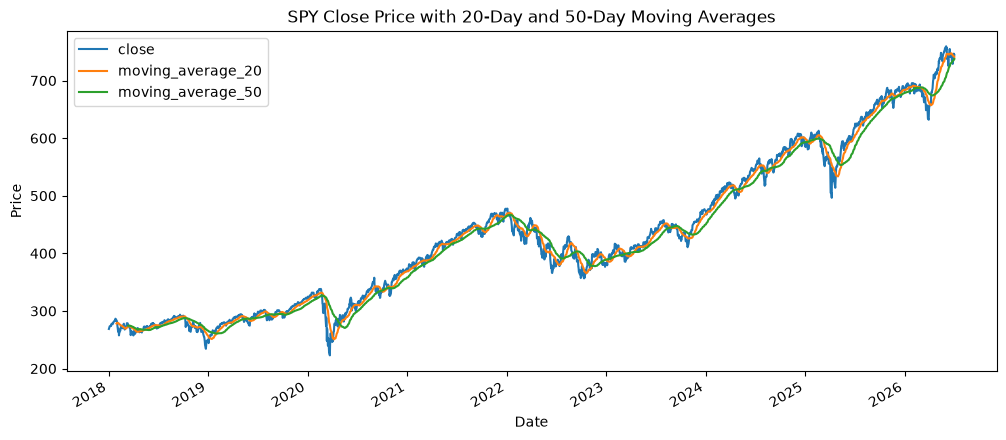

In [16]:
plot_df = df.copy()

ax = plot_df.plot(
    x="date",
    y=["close", "moving_average_20", "moving_average_50"],
    figsize=(12, 5),
    title="SPY Close Price with 20-Day and 50-Day Moving Averages"
)

ax.set_xlabel("Date")
ax.set_ylabel("Price")

#### Save feature dataset

In [17]:
output_path = PROCESSED_DIR / "marketlens_features.csv"

df.to_csv(output_path, index=False)

print(f"Feature dataset saved to: {output_path}")
print(f"Rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Feature dataset saved to: C:\Users\Wilson\Documents\OpenAI\MarketLens\data\processed\marketlens_features.csv
Rows: 2136
Columns: ['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'dgs10', 'daily_return', 'cumulative_return', 'moving_average_20', 'moving_average_50', 'rolling_volatility_20', 'rsi_14', 'running_max_close', 'drawdown', 'trend_status']


#### Reload and verify saved dataset

In [18]:
saved_check = pd.read_csv(output_path)

print("Saved feature dataset shape:", saved_check.shape)
print("Saved feature dataset columns:")
print(saved_check.columns.tolist())

display(saved_check.head())
display(saved_check.tail())

Saved feature dataset shape: (2136, 17)
Saved feature dataset columns:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'dgs10', 'daily_return', 'cumulative_return', 'moving_average_20', 'moving_average_50', 'rolling_volatility_20', 'rsi_14', 'running_max_close', 'drawdown', 'trend_status']


,date,open,high,low,close,adj_close,volume,dgs10,daily_return,cumulative_return,moving_average_20,moving_average_50,rolling_volatility_20,rsi_14,running_max_close,drawdown,trend_status
0,2018-01-02,267.839996,268.809998,267.399994,268.769989,235.954208,86655700,2.46,NaN,0.000000,NaN,NaN,NaN,NaN,268.769989,0.0,Insufficient data
1,2018-01-03,268.959991,270.640015,268.959991,270.470001,237.446716,90070400,2.44,0.006325,0.006325,NaN,NaN,NaN,NaN,270.470001,0.0,Insufficient data
2,2018-01-04,271.200012,272.160004,270.540009,271.609985,238.447495,80636400,2.46,0.004215,0.010567,NaN,NaN,NaN,NaN,271.609985,0.0,Insufficient data
3,2018-01-05,272.510010,273.559998,271.950012,273.420013,240.036560,83524000,2.47,0.006664,0.017301,NaN,NaN,NaN,NaN,273.420013,0.0,Insufficient data
4,2018-01-08,273.309998,274.100006,272.980011,273.920013,240.475525,57319200,2.49,0.001829,0.019161,NaN,NaN,NaN,NaN,273.920013,0.0,Insufficient data


,date,open,high,low,close,adj_close,volume,dgs10,daily_return,cumulative_return,moving_average_20,moving_average_50,rolling_volatility_20,rsi_14,running_max_close,drawdown,trend_status
2131,2026-06-26,728.950012,736.530029,716.580017,728.989990,728.989990,71034000,4.38,-0.007231,1.712319,743.601999,734.351400,0.167221,44.927706,759.570007,-0.040260,Below 50-day average
2132,2026-06-29,736.530029,741.559998,732.090027,741.000000,741.000000,58035200,4.38,0.016475,1.757004,742.828000,735.138201,0.178805,50.939627,759.570007,-0.024448,Above 50-day average
2133,2026-06-30,741.289978,748.020020,740.890015,746.770020,746.770020,55626000,4.44,0.007787,1.778472,742.239502,735.870801,0.181082,54.943059,759.570007,-0.016852,Above 50-day average
2134,2026-07-01,745.000000,749.440002,742.380005,745.760010,745.760010,47100900,4.48,-0.001353,1.774715,741.549002,736.611602,0.180925,61.589335,759.570007,-0.018181,Above 50-day average
2135,2026-07-02,747.400024,751.309998,740.030029,744.780029,744.780029,57447800,4.48,-0.001314,1.771068,741.076004,737.425602,0.179475,54.596661,759.570007,-0.019472,Above 50-day average


#### Save feature engineering report

In [19]:
from datetime import datetime

report_path = REPORTS_DIR / "feature_engineering_check.txt"

report = f"""
MarketLens Feature Engineering Check

Status: Feature engineering completed.
Timestamp: {datetime.now()}

Input file:
- data/processed/marketlens_dataset.csv

Output file:
- data/processed/marketlens_features.csv

Rows in final dataset: {len(df)}
Columns in final dataset: {df.columns.tolist()}

Features added:
- daily_return
- cumulative_return
- moving_average_20
- moving_average_50
- rolling_volatility_20
- rsi_14
- running_max_close
- drawdown
- trend_status

Date range:
- Start date: {df["date"].min()}
- End date: {df["date"].max()}

Missing values:
{df.isna().sum().to_string()}

Note:
This dataset is for educational and portfolio demonstration only. It does not prove that any trading or investment strategy is profitable.
"""

report_path.write_text(report.strip(), encoding="utf-8")

print(f"Report saved to: {report_path}")

Report saved to: C:\Users\Wilson\Documents\OpenAI\MarketLens\reports\feature_engineering_check.txt
